In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("D:\DataScience\Data\CustomerChurn\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\CM\AppData\Local\Temp\ipykernel_6856\2137739601.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\DataScience\Data\CustomerChurn\WA_Fn-UseC_-Telco-Customer-Churn.csv")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

In [6]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [7]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['TotalCharges'].dtype
df['TotalCharges'].isnull().sum()

np.int64(0)

In [9]:
y = df['Churn']
X = df.drop(columns=['Churn'])


In [10]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

print("Numerical columns:",num_cols, len(num_cols))
print("Categorical columns:",cat_cols, len(cat_cols))


Numerical columns: Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object') 3
Categorical columns: Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object') 17


In [11]:
# check number of unique values
cardinality = X[cat_cols].nunique().sort_values(ascending=False)
cardinality.head(20)

customerID          7043
PaymentMethod          4
InternetService        3
MultipleLines          3
OnlineSecurity         3
DeviceProtection       3
TechSupport            3
OnlineBackup           3
StreamingTV            3
Contract               3
StreamingMovies        3
PhoneService           2
Dependents             2
gender                 2
SeniorCitizen          2
Partner                2
PaperlessBilling       2
dtype: int64

In [12]:
high_cardinality_cols = [
    col for col in cat_cols if X[col].nunique() > 50
]

X = X.drop(columns=high_cardinality_cols)


In [13]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [14]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns


In [15]:
X_encoded = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

X_encoded.shape


(7043, 30)

In [16]:
X_encoded

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,1990.50,True,False,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,72,103.20,7362.90,False,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,11,29.60,346.45,False,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,4,74.40,306.60,True,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)


In [18]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns
)

X_scaled.head()


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.277445,-1.160323,-0.994242,-1.009559,-0.439916,1.034530,-0.654012,-3.054010,3.054010,-0.854176,...,-0.525927,-0.790132,-0.525927,-0.79607,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807
1,0.066327,-0.259629,-0.173244,0.990532,-0.439916,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.525927,-0.790132,-0.525927,-0.79607,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,1.835513
2,-1.236724,-0.362660,-0.959674,0.990532,-0.439916,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.525927,-0.790132,-0.525927,-0.79607,-0.514249,-0.562975,0.829798,-0.525047,-0.711026,1.835513
3,0.514251,-0.746535,-0.194766,0.990532,-0.439916,-0.966622,-0.654012,-3.054010,3.054010,-0.854176,...,-0.525927,-0.790132,-0.525927,-0.79607,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,-0.544807
4,-1.236724,0.197365,-0.940470,-1.009559,-0.439916,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.525927,-0.790132,-0.525927,-0.79607,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807


In [19]:
corr_matrix = X_scaled.corr()

corr_matrix.abs().unstack()\
    .sort_values(ascending=False)\
    .drop_duplicates()\
    .head(15)


PaymentMethod_Mailed check        PaymentMethod_Mailed check        1.000000
PhoneService_Yes                  MultipleLines_No phone service    1.000000
TotalCharges                      tenure                            0.825464
InternetService_Fiber optic       MonthlyCharges                    0.787066
OnlineBackup_No internet service  MonthlyCharges                    0.763557
TotalCharges                      MonthlyCharges                    0.650864
StreamingTV_Yes                   MonthlyCharges                    0.629603
StreamingMovies_Yes               MonthlyCharges                    0.627429
Contract_Two year                 tenure                            0.558533
StreamingMovies_Yes               StreamingTV_Yes                   0.533094
TotalCharges                      DeviceProtection_Yes              0.522374
                                  StreamingMovies_Yes               0.519884
                                  StreamingTV_Yes                   0.515279

In [20]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


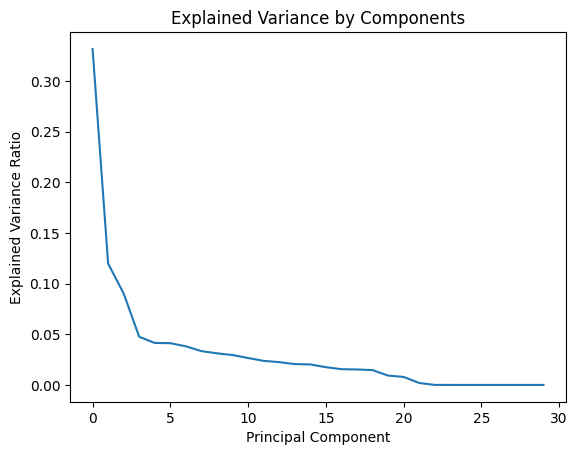

In [21]:
explained_variance = pca.explained_variance_ratio_

import matplotlib.pyplot as plt

plt.plot(explained_variance)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Components")
plt.show()


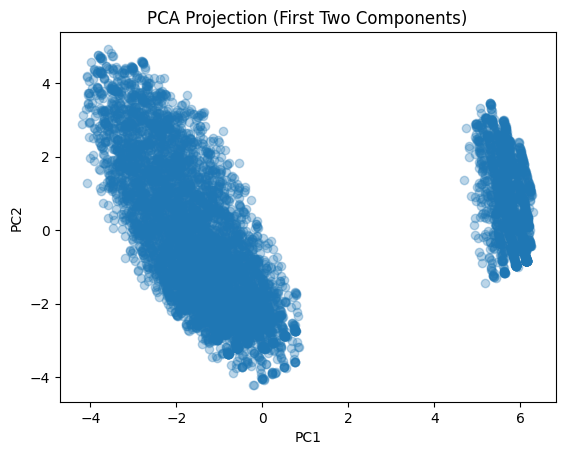

In [22]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (First Two Components)")
plt.show()


Kmeans

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))


Plot Elbow curve & silhouette scores
You are looking for the point where improvement slows down — the “elbow.”
Silhouette helps detect over-clustering. If score drops after some K, you are forcing divisions.

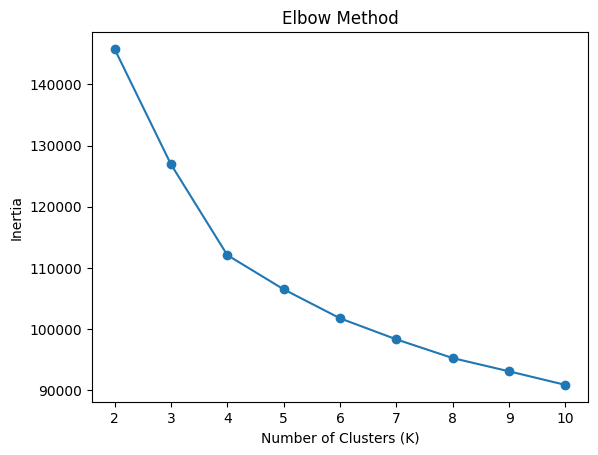

In [24]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


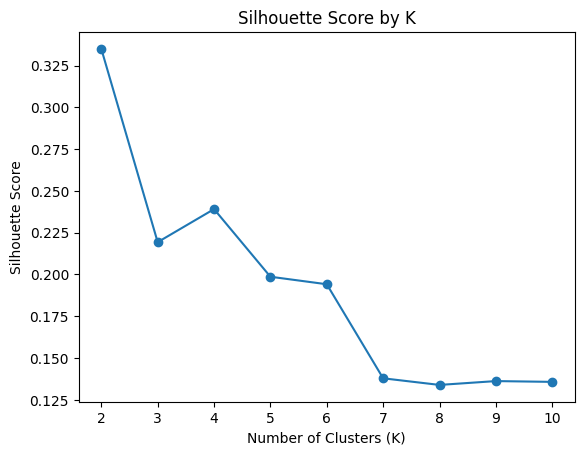

In [25]:
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.show()


In [26]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

X_scaled['Cluster'] = clusters


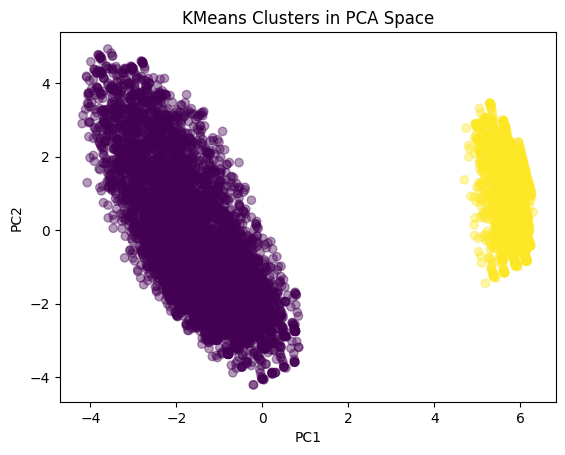

In [27]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters in PCA Space")
plt.show()


In [28]:
df_clustered = df.copy()
df_clustered['Cluster'] = clusters

In [29]:
df_clustered.groupby('Cluster')[num_cols].mean()

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,32.875657,76.844254,2728.298201
1,30.547182,21.079194,668.099443


In [30]:
df_clustered.groupby('Cluster')['Churn'].value_counts(normalize=True)


Cluster  Churn
0        0        0.681711
         1        0.318289
1        0        0.925950
         1        0.074050
Name: proportion, dtype: float64

In [31]:
for col in cat_cols:
    print("\n", col)
    print(df_clustered.groupby('Cluster')[col].value_counts(normalize=True))



 gender
Cluster  gender
0        Male      0.503172
         Female    0.496828
1        Male      0.510485
         Female    0.489515
Name: proportion, dtype: float64

 SeniorCitizen
Cluster  SeniorCitizen
0        0                0.802429
         1                0.197571
1        0                0.965924
         1                0.034076
Name: proportion, dtype: float64

 Partner
Cluster  Partner
0        No         0.517129
         Yes        0.482871
1        No         0.516383
         Yes        0.483617
Name: proportion, dtype: float64

 Dependents
Cluster  Dependents
0        No            0.734095
         Yes           0.265905
1        No            0.578637
         Yes           0.421363
Name: proportion, dtype: float64

 PhoneService
Cluster  PhoneService
0        Yes             0.876382
         No              0.123618
1        Yes             1.000000
Name: proportion, dtype: float64

 MultipleLines
Cluster  MultipleLines   
0        Yes                 0.476

In [32]:
df_clustered.groupby('Cluster')['Churn'].mean()


Cluster
0    0.318289
1    0.074050
Name: Churn, dtype: float64

In [33]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,   # assume ~3% anomalies
    random_state=42
)

anomaly_labels = iso.fit_predict(X_scaled)


In [34]:
df_clustered['Anomaly'] = anomaly_labels


In [35]:
df_clustered['Anomaly'].value_counts()


Anomaly
 1    6831
-1     212
Name: count, dtype: int64

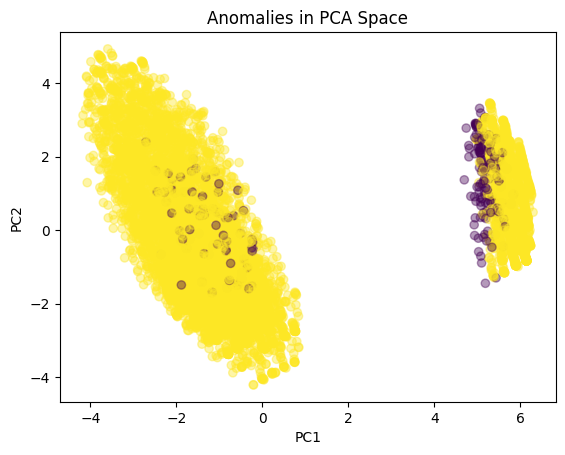

In [36]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_clustered['Anomaly'],
    alpha=0.4
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalies in PCA Space")
plt.show()


In [37]:
df_clustered[df_clustered['Anomaly'] == -1].head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster,Anomaly
71,0731-EBJQB,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,One year,Yes,Electronic check,20.40,1090.65,0,1,-1
79,3887-PBQAO,Female,0,Yes,Yes,45,Yes,Yes,No,No internet service,...,No internet service,No internet service,One year,Yes,Credit card (automatic),25.90,1216.60,0,1,-1
103,5386-THSLQ,Female,1,Yes,No,66,No,No phone service,DSL,No,...,Yes,No,One year,No,Bank transfer (automatic),45.55,3027.25,0,0,-1
129,2639-UGMAZ,Male,1,No,No,71,No,No phone service,DSL,Yes,...,Yes,Yes,One year,Yes,Electronic check,56.45,3985.35,0,0,-1
135,7799-LGRDP,Female,0,No,No,43,Yes,Yes,No,No internet service,...,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.70,1188.20,0,1,-1


In [38]:
df_clustered.groupby('Anomaly')[num_cols].mean()


,tenure,MonthlyCharges,TotalCharges
Anomaly,,,
-1,44.726415,33.409906,1462.930542
1,31.987703,65.734695,2307.334160
